In [4]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.6 MB/s eta 0:00:00


# modelo

In [ ]:

!unzip fer-13.zip -d fer2013
!unzip runs.zip -d runs

In [7]:
import os
from glob import glob

classes = ["angry","disgust","fear","happy","neutral","sad","surprise"]

def convert(dataset_path, out_path):
    os.makedirs(out_path+"/images", exist_ok=True)
    os.makedirs(out_path+"/labels", exist_ok=True)

    for i, cls in enumerate(classes):
        imgs = glob(os.path.join(dataset_path, cls, "*.jpg"))
        for img_path in imgs:
            # copiar imagem
            fname = os.path.basename(img_path)
            new_img_path = os.path.join(out_path, "images", fname)
            os.system(f"cp {img_path} {new_img_path}")

            # gerar label cobrindo toda a imagem
            label_path = os.path.join(out_path, "labels", fname.replace(".jpg", ".txt"))
            with open(label_path, "w") as f:
                # YOLO format: class x_center y_center width height
                f.write(f"{i} 0.5 0.5 1.0 1.0\n")

convert("fer2013/train", "dataset/train")
convert("fer2013/test", "dataset/val")

In [8]:
from ultralytics import YOLO
model = YOLO("yolo12n.pt")


model.train(
    data = "/content/data.yaml",
    epochs = 10,
    imgsz = 64, # tamanho das img
    batch = 32
)




Ultralytics 8.3.205 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c0f9aeea5d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

# metricas do modelo

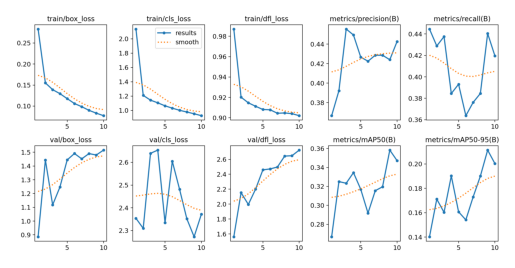

In [10]:
import matplotlib.pyplot as plt
import cv2

img = cv2.imread("runs/detect/train3/results.png")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

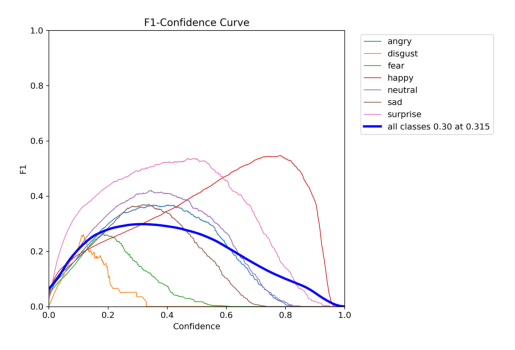

In [12]:
img2 = cv2.imread("/content/runs/detect/train3/BoxF1_curve.png")
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

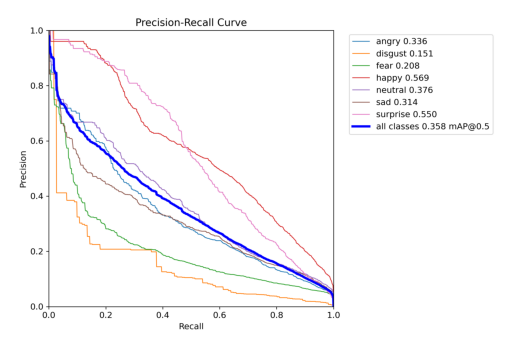

In [17]:
img4 = cv2.imread("/content/runs/detect/train3/BoxPR_curve.png")
plt.imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

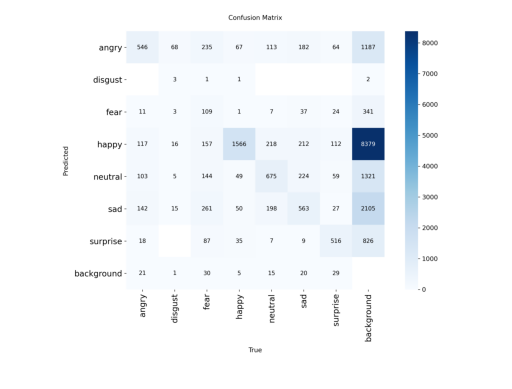

In [13]:
img3 = cv2.imread("/content/runs/detect/train3/confusion_matrix.png")
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

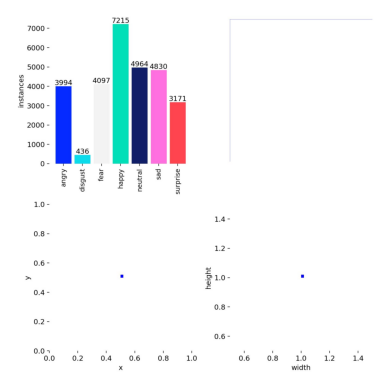

In [20]:
img5 = cv2.imread("/content/runs/detect/train3/labels.jpg")
plt.imshow(cv2.cvtColor(img5, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# backup do modelo salvo com o melhor peso *texto em itálico*

In [5]:
from ultralytics import YOLO
model = YOLO("/content/runs/runs/detect/train3/weights/best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
results = model("/content/Captura de tela 2025-10-04 184850.png", show=True)

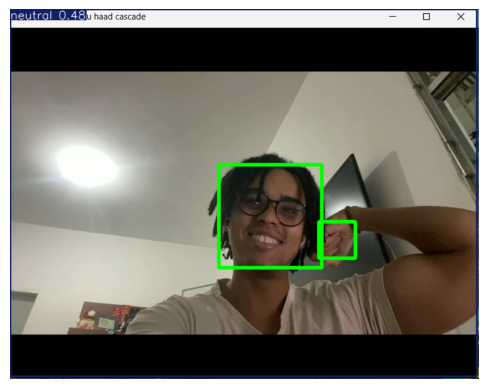

In [12]:
result = results[0]
img = result.plot()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# checkpoint save game

In [18]:
!zip -r runs.zip runs/


  adding: runs/ (stored 0%)
  adding: runs/detect/ (stored 0%)
  adding: runs/detect/train/ (stored 0%)
  adding: runs/detect/train/args.yaml (deflated 53%)
  adding: runs/detect/train/weights/ (stored 0%)
  adding: runs/detect/train2/ (stored 0%)
  adding: runs/detect/train2/args.yaml (deflated 53%)
  adding: runs/detect/train2/weights/ (stored 0%)
  adding: runs/detect/train3/ (stored 0%)
  adding: runs/detect/train3/results.csv (deflated 57%)
  adding: runs/detect/train3/labels.jpg (deflated 49%)
  adding: runs/detect/train3/args.yaml (deflated 53%)
  adding: runs/detect/train3/results.png (deflated 7%)
  adding: runs/detect/train3/BoxPR_curve.png (deflated 7%)
  adding: runs/detect/train3/val_batch1_labels.jpg (deflated 21%)
  adding: runs/detect/train3/val_batch0_pred.jpg (deflated 11%)
  adding: runs/detect/train3/val_batch1_pred.jpg (deflated 10%)
  adding: runs/detect/train3/train_batch2.jpg (deflated 3%)
  adding: runs/detect/train3/BoxP_curve.png (deflated 5%)
  adding: runs/

In [19]:
from google.colab import files
files.download("runs.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>